# Emittance

The emittance gives a measure of the phase space occupied by the beam. 

A beam at a given location in an accelerator can either be defined in terms of twiss paramers $\alpha$, $\beta$ and $\gamma$ or sigma $\sigma_{11}$, $\sigma_{22}$ and $\sigma_{12}$. They are related by 

$$
\begin{eqnarray}
\left<x^2          \right> & = & \beta \epsilon \\
\left<x^{\prime2} \right>& = & \gamma \epsilon \\
\left<x x^{\prime} \right> & = & -\alpha \epsilon
\end{eqnarray}
$$

This is typically written as a matrix 

$$
\Sigma = \begin{bmatrix} 
            \sigma_{11} & \sigma_{12} \\
            \sigma_{21} & \sigma_{22}
         \end{bmatrix}
       =  \begin{bmatrix} 
            \left< x^2 \right> & \left< x x^{\prime} \right> \\
            \left< x^{\prime} x \right> & \left< x^{\prime 2}\right>
         \end{bmatrix} 
$$

The emittance is the square root of the determinant of this sigma matriz 

$$ 
\epsilon = \sqrt{\det \Sigma} = \sqrt{\sigma_{11} \sigma_{22} - \sigma_{12}^2} = \sqrt{\left< x^2 \right> \left< x^{\prime 2}\right> - \left< x x^{\prime} \right>^2}
$$

Once the emittance is known, it is possible to calculate the $\alpha$, $\beta$ and $\gamma$ functions, as 

$$
\begin{eqnarray}
\beta  & = & \frac{\left<x^2\right>}{\epsilon} \\
\gamma & = & \frac{\left<x^{\prime2} \right>}{\epsilon} \\
\alpha & = & - \frac{\left<x x^{\prime} \right>}{\epsilon}
\end{eqnarray}
$$


## Function to generate a beam phase space

In [2]:
import numpy as np

def gam(alp, bet) :
    return (1+alp**2)/bet

def phase_space(emit, alp, bet, nparticle=1000) :
    gamma = gam(alp, bet)
    sigma_11 = bet*emit
    sigma_22 = gamma*emit
    sigma_12 = -alp*emit
    sigma_21 = -alp*emit

    rng = np.random.default_rng(seed=42)
    
    samples = rng.multivariate_normal(mean=[0, 0], cov=[[sigma_11, sigma_12],[sigma_21, sigma_22]], size=nparticle)
    return samples

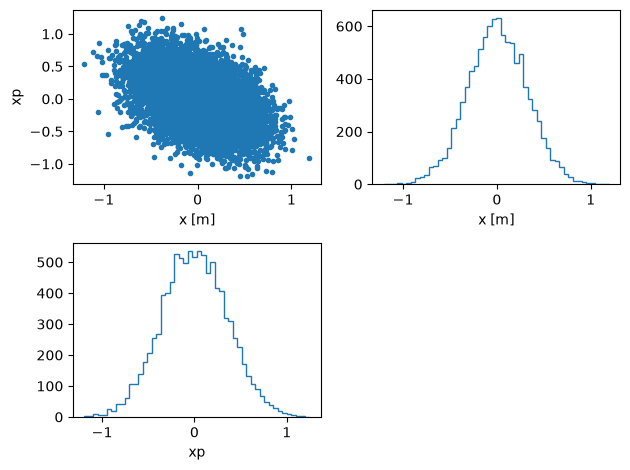

In [16]:
import matplotlib.pyplot as plt
ps = phase_space(emit=0.1,alp=0.5,bet=1, nparticle=10000)

plt.subplot(2,2,1)
plt.plot(ps[:,0], ps[:,1],'.')
plt.xlabel("x [m]");
plt.ylabel("xp");

plt.subplot(2,2,2)
plt.hist(ps[:,0],bins=50, histtype="step")
plt.xlabel("x [m]");

plt.subplot(2,2,3)
plt.hist(ps[:,1],bins=50, histtype="step")
plt.xlabel("xp");

plt.tight_layout()

## Exercises

1. Calculate emittance, alpha, beta and gamma from the phase space file on Canvas